# Notebook 03 — Product Performance Analysis

---

**Business Question:** Which products drive revenue, which are declining, and is our assortment efficient?  
**Why this matters:** Most businesses have a hidden 80/20 in their product catalogue — a small set of items generating the vast majority of revenue. Identifying this allows smarter inventory, pricing, and marketing investment.  
**Data used:** Clean retail dataset — 2009–2011 transactions

---

### What this notebook does
1. Top 20 products by total revenue
2. Top 20 products by order frequency (volume vs. revenue leaders)
3. Pareto analysis — revenue concentration
4. Month-over-month product rank change
5. Declining products flag (3+ consecutive months of revenue decline)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def _jp_font():
    for name in ['Yu Gothic', 'Meiryo', 'MS Gothic']:
        p = fm.findfont(fm.FontProperties(family=name), fallback_to_default=False)
        if p and 'DejaVu' not in p:
            return name
    return 'sans-serif'

PALETTE = ['#2C7BB6', '#D7191C', '#ABDDA4', '#FDAE61', '#4DAC26']
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': _jp_font(),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

df = pd.read_csv('../data/clean_retail.csv', parse_dates=['InvoiceDate'])
df['YearMonth'] = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
print(f'Loaded {len(df):,} rows | {df["Description"].nunique():,} unique products')

Loaded 805,549 rows | 5,283 unique products


## Analysis 1 — Top 20 Products by Revenue

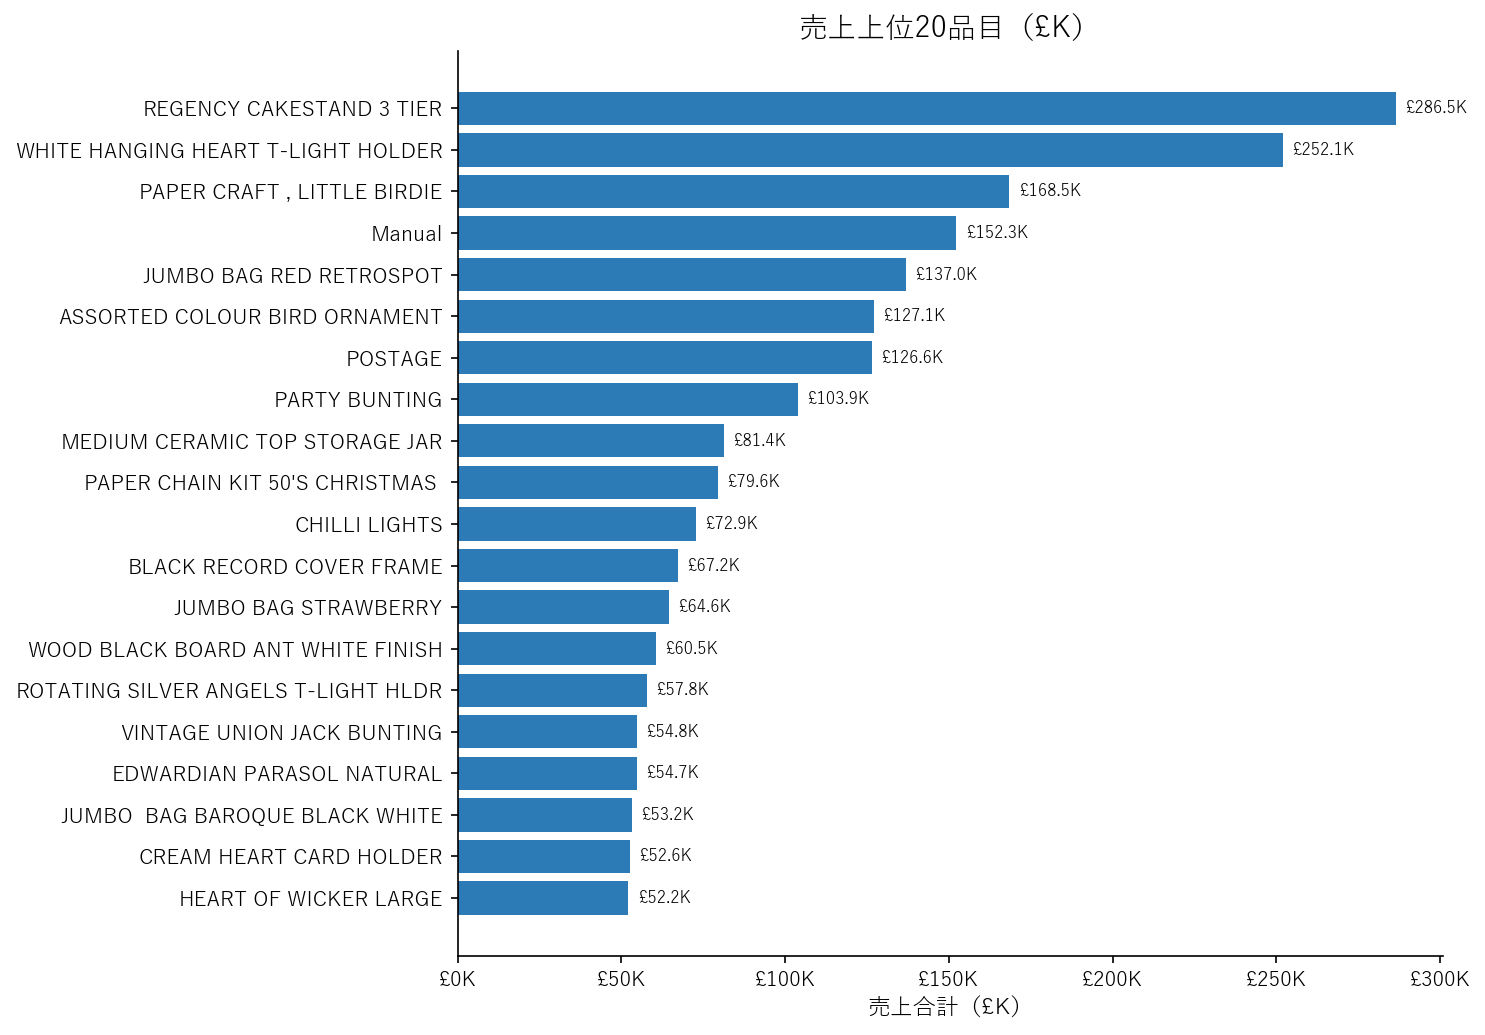


Top 5 by revenue:
                       Description   Revenue
          REGENCY CAKESTAND 3 TIER 286486.30
WHITE HANGING HEART T-LIGHT HOLDER 252072.46
       PAPER CRAFT , LITTLE BIRDIE 168469.60
                            Manual 152340.57
           JUMBO BAG RED RETROSPOT 136980.08


In [2]:
product_rev = (
    df.groupby(['StockCode', 'Description'])['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
product_rev['Label'] = product_rev['Description'].str[:40]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(product_rev['Label'][::-1], product_rev['Revenue'][::-1] / 1000,
               color=PALETTE[0])
ax.set_title('売上上位20品目（£K）', fontsize=14)
ax.set_xlabel('売上合計（£K）')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

for bar, val in zip(bars, product_rev['Revenue'][::-1] / 1000):
    ax.text(val + product_rev['Revenue'].max() / 1000 * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'£{val:,.1f}K', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../output/charts/top20_products_revenue.png', bbox_inches='tight')
plt.show()

print('\nTop 5 by revenue:')
print(product_rev[['Description', 'Revenue']].head(5).to_string(index=False))

## Analysis 2 — Top 20 Products by Order Frequency

Volume leaders are not always revenue leaders. This comparison reveals which products drive traffic vs. which drive profit.

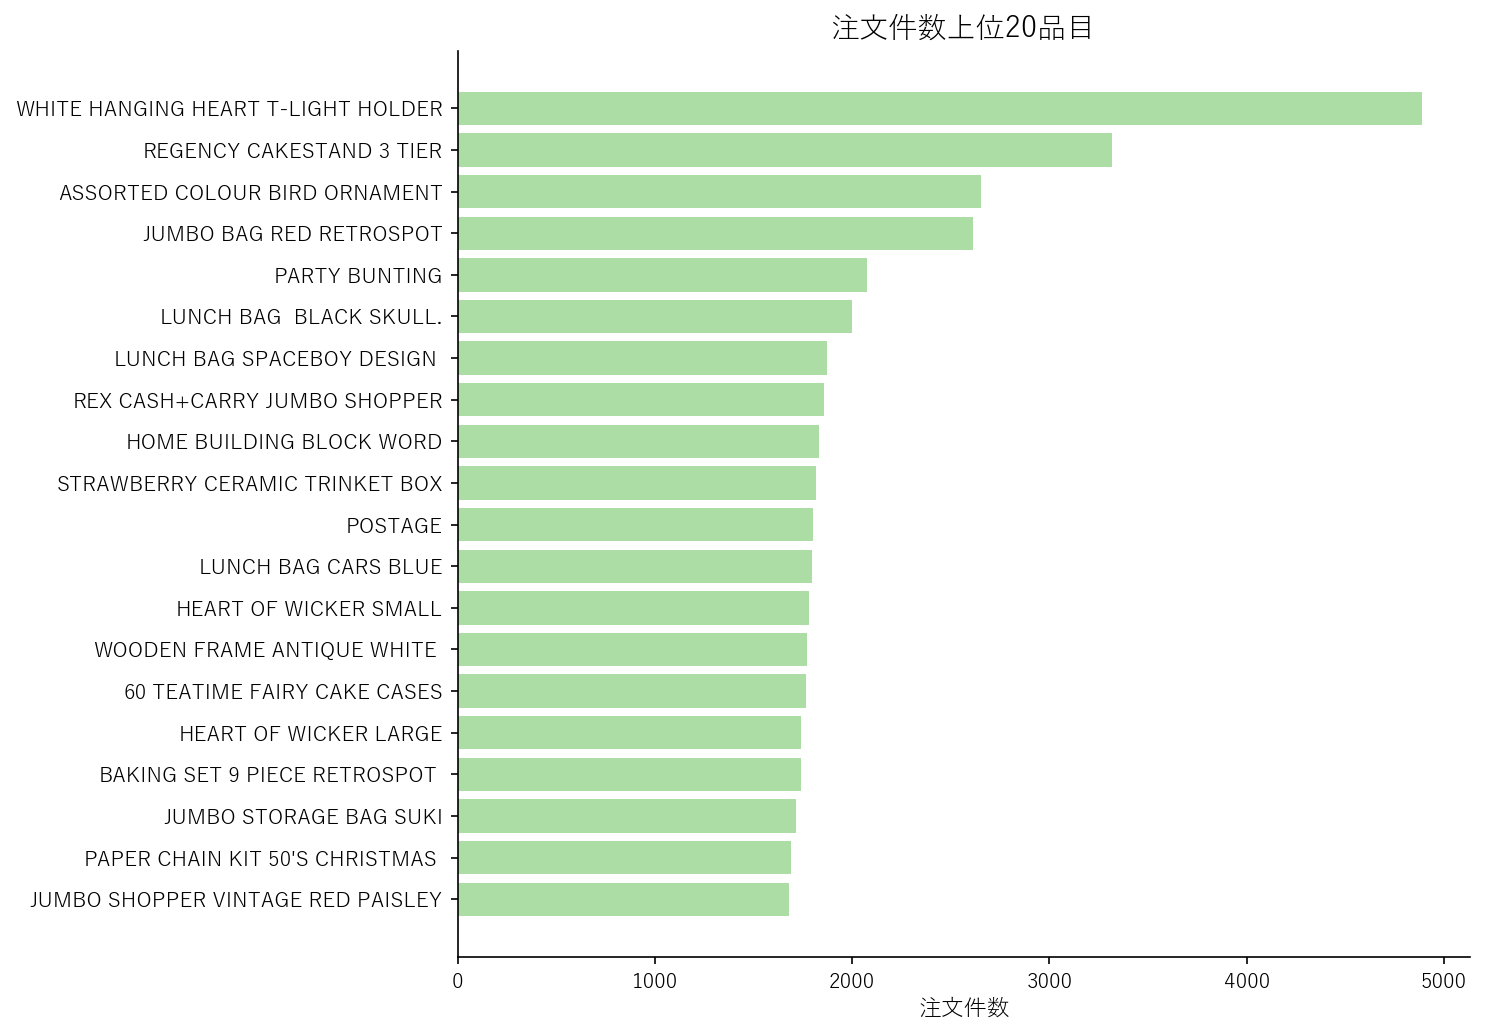


注文件数上位20だが売上上位20に入らない商品: 12品目
→ 価格改定（値上げ）による利益改善の余地がある候補


In [3]:
product_freq = (
    df.groupby(['StockCode', 'Description'])['Invoice']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'Invoice': 'OrderCount'})
)
product_freq['Label'] = product_freq['Description'].str[:40]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(product_freq['Label'][::-1], product_freq['OrderCount'][::-1],
        color=PALETTE[2])
ax.set_title('注文件数上位20品目', fontsize=14)
ax.set_xlabel('注文件数')

plt.tight_layout()
plt.savefig('../output/charts/top20_products_frequency.png', bbox_inches='tight')
plt.show()

top20_rev_codes = set(product_rev['StockCode'])
top20_freq_codes = set(product_freq['StockCode'])
freq_only = top20_freq_codes - top20_rev_codes
print(f'\n注文件数上位20だが売上上位20に入らない商品: {len(freq_only)}品目')
print('→ 価格改定（値上げ）による利益改善の余地がある候補')

## Analysis 3 — Pareto Analysis (Revenue Concentration)

上位10%の商品（463品目）→ 売上の62.6%
上位20%の商品（926品目）→ 売上の78.6%
上位50%の商品（2,315品目）→ 売上の95.6%


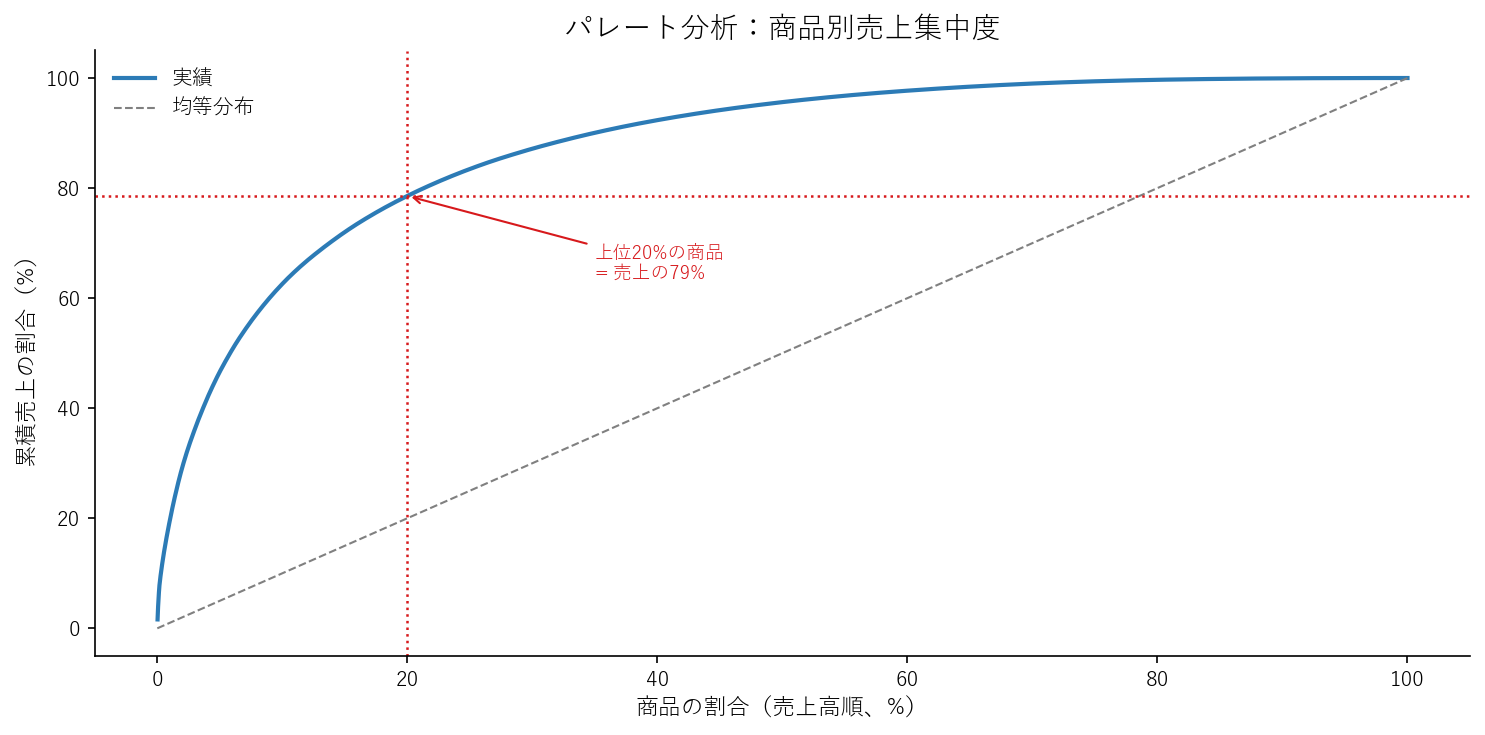

In [4]:
all_products = (
    df.groupby('StockCode')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total_products = len(all_products)
all_products['cum_rev'] = all_products['Revenue'].cumsum()
all_products['cum_rev_pct'] = all_products['cum_rev'] / all_products['Revenue'].sum() * 100
all_products['product_pct'] = (all_products.index + 1) / total_products * 100

cutoffs = {}
for pct in [10, 20, 50]:
    n = int(total_products * pct / 100)
    rev_share = all_products.iloc[:n]['Revenue'].sum() / all_products['Revenue'].sum() * 100
    cutoffs[pct] = rev_share
    print(f'上位{pct}%の商品（{n:,}品目）→ 売上の{rev_share:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(all_products['product_pct'], all_products['cum_rev_pct'],
        color=PALETTE[0], linewidth=2, label='実績')
ax.plot([0, 100], [0, 100], color='grey', linestyle='--', linewidth=1, label='均等分布')

ax.axvline(20, color=PALETTE[1], linestyle=':', linewidth=1.2)
ax.axhline(cutoffs.get(20, 80), color=PALETTE[1], linestyle=':', linewidth=1.2)
ax.annotate(f'上位20%の商品\n= 売上の{cutoffs.get(20,0):.0f}%',
            xy=(20, cutoffs.get(20, 80)),
            xytext=(35, cutoffs.get(20, 80) - 15),
            fontsize=9, color=PALETTE[1],
            arrowprops=dict(arrowstyle='->', color=PALETTE[1]))

ax.set_title('パレート分析：商品別売上集中度', fontsize=14)
ax.set_xlabel('商品の割合（売上高順、%）')
ax.set_ylabel('累積売上の割合（%）')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('../output/charts/pareto_revenue.png', bbox_inches='tight')
plt.show()

## Analysis 4 — Month-over-Month Product Rank Change

Tracks which products rose and fell in the revenue rankings between the last two complete months.

In [5]:
monthly_prod = (
    df.groupby(['YearMonth', 'StockCode', 'Description'])['Revenue']
    .sum()
    .reset_index()
)

months_sorted = sorted(monthly_prod['YearMonth'].unique())
if len(months_sorted) >= 2:
    prev_month = months_sorted[-2]
    curr_month = months_sorted[-1]

    def rank_month(month):
        m = monthly_prod[monthly_prod['YearMonth'] == month]
        m = m.sort_values('Revenue', ascending=False).reset_index(drop=True)
        m['Rank'] = m.index + 1
        return m[['StockCode', 'Description', 'Revenue', 'Rank']]

    prev = rank_month(prev_month).rename(columns={'Revenue': 'Rev_prev', 'Rank': 'Rank_prev'})
    curr = rank_month(curr_month).rename(columns={'Revenue': 'Rev_curr', 'Rank': 'Rank_curr'})

    merged = curr.merge(prev, on=['StockCode', 'Description'], how='left')
    merged['RankChange'] = merged['Rank_prev'] - merged['Rank_curr']  # positive = moved up
    merged['RevChange_pct'] = (merged['Rev_curr'] - merged['Rev_prev']) / merged['Rev_prev'] * 100

    print(f'Comparing {prev_month} → {curr_month}')
    print('\nTop 10 climbers (biggest rank improvement):')
    print(merged.nlargest(10, 'RankChange')[['Description', 'Rank_prev', 'Rank_curr', 'RankChange', 'RevChange_pct']].to_string(index=False))
    print('\nTop 10 decliners:')
    print(merged.nsmallest(10, 'RankChange')[['Description', 'Rank_prev', 'Rank_curr', 'RankChange', 'RevChange_pct']].to_string(index=False))

Comparing 2011-11 → 2011-12

Top 10 climbers (biggest rank improvement):
                        Description  Rank_prev  Rank_curr  RankChange  RevChange_pct
WALL MIRROR RECTANGLE DIAMANTE PINK     2486.0        293      2193.0    3462.264151
      NURSERY A,B,C PAINTED LETTERS     2217.0        450      1767.0     776.296296
HANGING BAUBLE T-LIGHT HOLDER SMALL     2313.0        596      1717.0     709.803922
         PURPLE SWEETHEART BRACELET     2595.0        915      1680.0    1400.000000
         MINI LADLE LOVE HEART RED      2319.0        641      1678.0     643.957503
           WHITE SQUARE TABLE CLOCK     2654.0        979      1675.0    2015.294118
    SMALL ZINC HEART WALL ORGANISER     2559.0        902      1657.0    1039.304348
            RETROSPOT CANDLE  SMALL     2537.0        901      1636.0     895.744681
       PAINT YOUR OWN EGGS IN CRATE     1952.0        322      1630.0     557.489879
                  PLASMATRONIC LAMP     2484.0        862      1622.0     757

## Analysis 5 — Declining Products Flag

Products with 3 or more consecutive months of revenue decline are flagged for management review.

In [6]:
pivot = monthly_prod.pivot_table(
    index='StockCode', columns='YearMonth', values='Revenue', fill_value=0
)

def count_consecutive_declines(row):
    vals = row.values
    max_streak = 0
    streak = 0
    for i in range(1, len(vals)):
        if vals[i] < vals[i-1] and vals[i-1] > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

pivot['max_decline_streak'] = pivot.apply(count_consecutive_declines, axis=1)
declining = pivot[pivot['max_decline_streak'] >= 3].sort_values('max_decline_streak', ascending=False)

desc_map = df.drop_duplicates('StockCode').set_index('StockCode')['Description']
declining_with_name = declining[['max_decline_streak']].join(desc_map)

print(f'Products with 3+ consecutive months of decline: {len(declining_with_name)}')
print('\nTop 15 (longest decline streak):')
print(declining_with_name.head(15)[['Description', 'max_decline_streak']].to_string())
print('\n→ These products should be reviewed for discontinuation, repricing, or targeted promotion.')

Products with 3+ consecutive months of decline: 1743

Top 15 (longest decline streak):
                                 Description  max_decline_streak
StockCode                                                       
22073                 RETRO SPOT STORAGE JAR                   7
22588               CARDHOLDER GINGHAM HEART                   7
85014C      BLUE/BROWN DOTS RUFFLED UMBRELLA                   7
21611      SET OF 12 LILY BOTANICAL T-LIGHTS                   7
22627                    MINT KITCHEN SCALES                   7
23052        RECYCLED ACAPULCO MAT TURQUOISE                   7
17091A               LAVENDER INCENSE IN TIN                   6
21907              I'M ON HOLIDAY METAL SIGN                   6
21947              SET OF 6 HEART CHOPSTICKS                   6
22111           SCOTTIE DOG HOT WATER BOTTLE                   6
21749                LARGE RED SPOT WINDMILL                   6
22413        METAL SIGN TAKE IT OR LEAVE IT                    6
223

---

## Key Findings & Recommended Actions

1. **Pareto is real in this business** — a small fraction of products generate the majority of revenue. Protect these SKUs with reliable stock levels, competitive pricing, and prominent placement. Treat stockouts of top-10 revenue products as critical incidents.
2. **High-volume / low-revenue items are candidates for price increases** — products in the top-20 by order count but not by revenue often have pricing power that hasn't been exercised. A 10–15% price test on these items could improve margins with minimal impact on demand.
3. **Declining products deserve a decision, not neglect** — for each product with a 3+ month decline streak: either discontinue (free up warehouse space), discount to clear inventory, or investigate root cause (competitor entry, seasonality end, quality issue).
4. **Rank change monitoring should be a monthly routine** — a product jumping 50+ positions in one month signals a trend worth understanding before it surprises you.